In [1]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay 
import pandas as pd
from sklearn.utils import shuffle
from sklearn.model_selection import cross_val_score, cross_val_predict, GridSearchCV
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

## Data prep

In [2]:
def numeric_columns(df):
    numeric_cols = []
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            numeric_cols.append(col)
    return numeric_cols
# Load dataset
df = pd.read_csv("15 features - no imp.csv")

# Use function to extract numeric columns
numeric_cols = numeric_columns(df)

# Create a copy of the DataFrame
df_numeric = df[numeric_cols].copy()

# Now you can safely modify df_numeric
df_numeric['mhw_category'] = df['mhw_category']

replace_category = {
    'none': 0,
    'Moderate': 1,
    'Strong': 2,
    'Severe': 3
}
df_numeric['mhw_category'] = df['mhw_category'].replace(replace_category)

print(df_numeric['mhw_category'].value_counts())

# Shuffle the DataFrame
shuffled_df_numeric = shuffle(df_numeric, random_state=42)

# Separate features (X) and labels (y) after shuffling
X = shuffled_df_numeric.drop(['mhw_category'], axis=1)
y = shuffled_df_numeric['mhw_category']
X.shape, y.shape

mhw_category
1    605
2    185
3     31
Name: count, dtype: int64


C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_16156\2797522876.py:25: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_numeric['mhw_category'] = df['mhw_category'].replace(replace_category)


((821, 15), (821,))

## Imputing with best imputation KNN imputer

In [3]:
nan = np.nan
imputer = KNNImputer(n_neighbors=7, weights="distance")
imputed = imputer.fit_transform(shuffled_df_numeric)

imputed_df = pd.DataFrame(imputed, columns = shuffled_df_numeric.columns)

# Shuffle the DataFrame
shuffled_imp = shuffle(imputed_df, random_state=42)

# Separate features (X) and labels (y) after shuffling
X_imp = shuffled_imp.drop(['mhw_category'], axis=1)
y_imp = shuffled_imp['mhw_category']
print(X_imp.shape, y_imp.shape)

(821, 15) (821,)


## First SVM clf

cross validation scores SVM: [0.87878788 0.83536585 0.87804878 0.84146341 0.84146341]
0.8550 accuracy with a standard deviation of 0.0192
Accuracy: 86.06%
SVM               precision    recall  f1-score   support

         1.0       0.91      0.90      0.91       122
         2.0       0.68      0.70      0.69        37
         3.0       1.00      1.00      1.00         6

    accuracy                           0.86       165
   macro avg       0.86      0.87      0.87       165
weighted avg       0.86      0.86      0.86       165

SVM <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x000001E9DBD8B070>


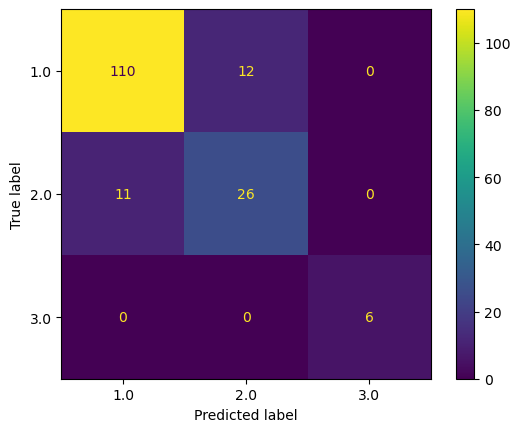

In [4]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_imp, y_imp, stratify = y_imp, test_size=0.2, random_state=42)
# Initialize the XGBClassifier
clf = SVC(class_weight = 'balanced', random_state = 42) 
model = Pipeline(
    steps=[("scaler", StandardScaler()), ("SVM", clf)]
)
# Train the model
model.fit(X_train, y_train)
# Make predictions
y_pred = model.predict(X_test)
# Evaluate the model
cross_val_scores = cross_val_score(model, X_imp, y_imp, cv=5)
print('cross validation scores SVM:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print('SVM', classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
#print('SVM', cm)
print('SVM', ConfusionMatrixDisplay.from_estimator(model, X_test, y_test))

## Grid search SVM

In [5]:
param_grid = [
     {'C': [1, 1.5, 2, 5],
      'class_weight': ['balanced', None],
      'gamma': ['scale', 'auto']
     }
]

grid = GridSearchCV(clf, param_grid, cv = 5, scoring = 'accuracy', verbose = 1)
model_grid = grid.fit(X_train, y_train)
print('the best score was', str(model_grid.best_score_))
print('the best parameters were', str(model_grid.best_params_))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
the best score was 0.9756187832523711
the best parameters were {'C': 2, 'class_weight': None, 'gamma': 'auto'}


In [6]:
param_grid = [
     {'C': [2, 3, 4],
      'gamma': ['auto'],
      'class_weight': [None]
     }
]

grid = GridSearchCV(clf, param_grid, cv = 5, scoring = 'accuracy', verbose = 2)
model_grid = grid.fit(X_train, y_train)
print('the best score was', str(model_grid.best_score_))
print('the best parameters were', str(model_grid.best_params_))
pd.DataFrame(model_grid.cv_results_)

Fitting 5 folds for each of 3 candidates, totalling 15 fits
[CV] END .................C=2, class_weight=None, gamma=auto; total time=   0.0s
[CV] END .................C=2, class_weight=None, gamma=auto; total time=   0.0s
[CV] END .................C=2, class_weight=None, gamma=auto; total time=   0.0s
[CV] END .................C=2, class_weight=None, gamma=auto; total time=   0.0s
[CV] END .................C=2, class_weight=None, gamma=auto; total time=   0.0s
[CV] END .................C=3, class_weight=None, gamma=auto; total time=   0.0s
[CV] END .................C=3, class_weight=None, gamma=auto; total time=   0.0s
[CV] END .................C=3, class_weight=None, gamma=auto; total time=   0.0s
[CV] END .................C=3, class_weight=None, gamma=auto; total time=   0.0s
[CV] END .................C=3, class_weight=None, gamma=auto; total time=   0.0s
[CV] END .................C=4, class_weight=None, gamma=auto; total time=   0.0s
[CV] END .................C=4, class_weight=None,

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_class_weight,param_gamma,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.047483,0.016602,0.017776,0.008016,2,None,auto,"{'C': 2, 'class_weight': None, 'gamma': 'auto'}",0.969697,0.961832,0.984733,0.984733,0.977099,0.975619,0.008871,1
1,0.061810,0.009903,0.016627,0.003388,3,None,auto,"{'C': 3, 'class_weight': None, 'gamma': 'auto'}",0.977273,0.961832,0.984733,0.984733,0.969466,0.975607,0.008908,2
2,0.051063,0.015213,0.015199,0.008762,4,None,auto,"{'C': 4, 'class_weight': None, 'gamma': 'auto'}",0.977273,0.961832,0.984733,0.969466,0.969466,0.972554,0.007805,3


cross validation scores: [0.92727273 0.8902439  0.92073171 0.90243902 0.91463415]
0.9111 accuracy with a standard deviation of 0.0132
Accuracy: 89.70%
              precision    recall  f1-score   support

         1.0       0.88      0.99      0.93       122
         2.0       0.95      0.57      0.71        37
         3.0       1.00      1.00      1.00         6

    accuracy                           0.90       165
   macro avg       0.95      0.85      0.88       165
weighted avg       0.90      0.90      0.89       165

[[121   1   0]
 [ 16  21   0]
 [  0   0   6]]


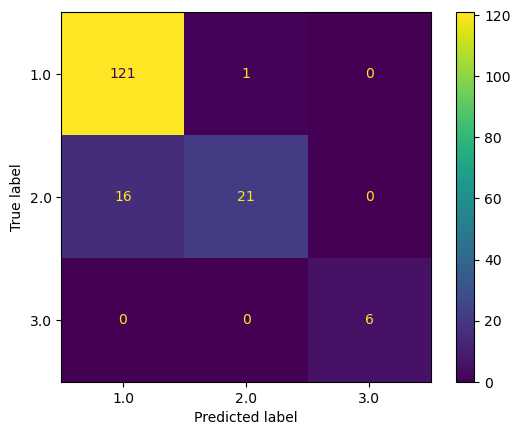

In [7]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_imp, y_imp, stratify = y_imp, test_size=0.2, random_state=42)
# Initialize the XGBClassifier
clf = SVC(C = 2, gamma = 'auto', class_weight = None, random_state = 42) 
model = Pipeline(
    steps=[("scaler", StandardScaler()), ("SVM", clf)]
)
# Train the model
model.fit(X_train, y_train)
# Make predictions
y_pred = model.predict(X_test)
# Evaluate the model
cross_val_scores = cross_val_score(model, X_imp, y_imp, cv=5)
print('cross validation scores:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print(cm)
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

In [30]:
nan = np.nan
imputer = KNNImputer(n_neighbors = 7, weights = 'uniform')
imputed = imputer.fit_transform(shuffled_df_numeric)
imputed_df = pd.DataFrame(imputed, columns = shuffled_df_numeric.columns)

# Shuffle the DataFrame
shuffled_imp = shuffle(imputed_df, random_state=42)

# Separate features (X) and labels (y) after shuffling
X_imp = shuffled_imp.drop(['mhw_category'], axis=1)
y_imp = shuffled_imp['mhw_category']

X_imp.shape

(821, 15)

cross validation scores SVM: [0.90909091 0.87195122 0.90243902 0.8902439  0.8902439 ]
0.8928 accuracy with a standard deviation of 0.0127
Accuracy: 87.27%
SVM               precision    recall  f1-score   support

         1.0       0.88      0.96      0.92       122
         2.0       0.81      0.57      0.67        37
         3.0       1.00      1.00      1.00         6

    accuracy                           0.87       165
   macro avg       0.90      0.84      0.86       165
weighted avg       0.87      0.87      0.86       165

SVM <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x000001E9FDB5EF80>


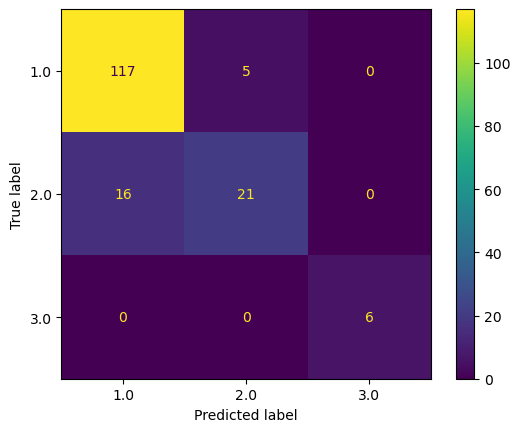

In [31]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_imp, y_imp, stratify = y_imp, test_size=0.2, random_state=42)
# Initialize the XGBClassifier
clf = SVC(class_weight = 'balanced', random_state = 42) 
model = Pipeline(
    steps=[("scaler", StandardScaler()), ("SVM", clf)]
)
# Train the model
model.fit(X_train, y_train)
# Make predictions
y_pred = model.predict(X_test)
# Evaluate the model
cross_val_scores = cross_val_score(model, X_imp, y_imp, cv=5)
print('cross validation scores SVM:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print('SVM', classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
#print('SVM', cm)
print('SVM', ConfusionMatrixDisplay.from_estimator(model, X_test, y_test))

In [32]:
param_grid = [
     {'C': [1, 1.5, 2, 5],
      'class_weight': ['balanced', None],
      'gamma': ['scale', 'auto']
     }
]

grid = GridSearchCV(clf, param_grid, cv = 5, scoring = 'accuracy', verbose = 1)
model_grid = grid.fit(X_train, y_train)
print('the best score was', str(model_grid.best_score_))
print('the best parameters were', str(model_grid.best_params_))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
the best score was 0.9771339347675225
the best parameters were {'C': 5, 'class_weight': None, 'gamma': 'auto'}


In [33]:
param_grid = [
     {'C': [4, 5, 6],
      'class_weight': [None],
      'gamma': ['auto']
     }
]

grid = GridSearchCV(clf, param_grid, cv = 5, scoring = 'accuracy', verbose = 1)
model_grid = grid.fit(X_train, y_train)
print('the best score was', str(model_grid.best_score_))
print('the best parameters were', str(model_grid.best_params_))
pd.DataFrame(model_grid.cv_results_)

Fitting 5 folds for each of 3 candidates, totalling 15 fits
the best score was 0.9771339347675225
the best parameters were {'C': 4, 'class_weight': None, 'gamma': 'auto'}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_class_weight,param_gamma,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.043409,0.015015,0.013437,0.003980,4,None,auto,"{'C': 4, 'class_weight': None, 'gamma': 'auto'}",0.977273,0.961832,0.984733,0.984733,0.977099,0.977134,0.008362,1
1,0.056207,0.005871,0.016101,0.002353,5,None,auto,"{'C': 5, 'class_weight': None, 'gamma': 'auto'}",0.977273,0.961832,0.984733,0.984733,0.977099,0.977134,0.008362,1
2,0.055530,0.007357,0.016051,0.004379,6,None,auto,"{'C': 6, 'class_weight': None, 'gamma': 'auto'}",0.977273,0.961832,0.984733,0.984733,0.977099,0.977134,0.008362,1


In [34]:
param_grid = [
     {'C': [3, 4],
      'class_weight': [None],
      'gamma': ['auto']
     }
]

grid = GridSearchCV(clf, param_grid, cv = 5, scoring = 'accuracy', verbose = 1)
model_grid = grid.fit(X_train, y_train)
print('the best score was', str(model_grid.best_score_))
print('the best parameters were', str(model_grid.best_params_))
pd.DataFrame(model_grid.cv_results_)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
the best score was 0.9771339347675225
the best parameters were {'C': 3, 'class_weight': None, 'gamma': 'auto'}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_class_weight,param_gamma,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.039736,0.012597,0.018324,0.005007,3,None,auto,"{'C': 3, 'class_weight': None, 'gamma': 'auto'}",0.977273,0.961832,0.984733,0.984733,0.977099,0.977134,0.008362,1
1,0.058954,0.008199,0.018969,0.003398,4,None,auto,"{'C': 4, 'class_weight': None, 'gamma': 'auto'}",0.977273,0.961832,0.984733,0.984733,0.977099,0.977134,0.008362,1


cross validation scores SVM: [0.92727273 0.88414634 0.92073171 0.89634146 0.90853659]
0.9074 accuracy with a standard deviation of 0.0157
Accuracy: 88.48%
SVM               precision    recall  f1-score   support

         1.0       0.87      0.99      0.93       122
         2.0       0.95      0.51      0.67        37
         3.0       1.00      1.00      1.00         6

    accuracy                           0.88       165
   macro avg       0.94      0.84      0.86       165
weighted avg       0.89      0.88      0.87       165

SVM <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x000001E9FD992E00>


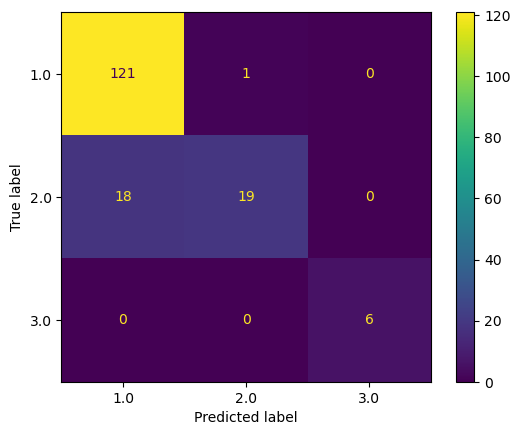

In [36]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_imp, y_imp, stratify = y_imp, test_size=0.2, random_state=42)
# Initialize the XGBClassifier
clf = SVC(class_weight = None, C = 3, gamma = 'auto', random_state = 42) 
model = Pipeline(
    steps=[("scaler", StandardScaler()), ("SVM", clf)]
)
# Train the model
model.fit(X_train, y_train)
# Make predictions
y_pred = model.predict(X_test)
# Evaluate the model
cross_val_scores = cross_val_score(model, X_imp, y_imp, cv=5)
print('cross validation scores SVM:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print('SVM', classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
#print('SVM', cm)
print('SVM', ConfusionMatrixDisplay.from_estimator(model, X_test, y_test))